In [3]:

import numpy as np
import matplotlib.pyplot as plt
from network import NetworkModel

N_AGENTS = 200
K = 6
P_REWIRE = 0.1
N_STEPS = 250
N_SEEDS = 10
EQUIL_WINDOW = 50
TAU_VALUES = [0.1, 0.3, 0.5, 1.0, 2.0]
LAM_VALUES = [1.0, 1.5, 2.0, 2.5, 3.0]
KAPPA_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8]
FIXED_TAU = 0.5 # held constant when sweeping lam_mean
FIXED_LAM = 2.0 # held constant when sweeping tau
FIXED_KAPPA = 0.0 # held constant when sweeping tau or lam_mean

AGE_MEAN_VALUES = [16, 17, 19, 21, 23, 24]
FIXED_AGE_MEAN = 20.0


def run_many_seeds(param_overrides: dict, n_seeds: int = N_SEEDS) -> np.ndarray:
    all_histories = np.empty((n_seeds, N_STEPS + 1, 3))
    for seed in range(n_seeds):
        model = NetworkModel(
            n_agents=N_AGENTS,
            k=K,
            p_rewire=P_REWIRE,
            seed=seed,
            **param_overrides,
        )
        history = model.run(N_STEPS)
        all_histories[seed, :, 0] = history["susceptible"]
        all_histories[seed, :, 1] = history["current_drinkers"]
        all_histories[seed, :, 2] = history["former_drinkers"]
    return all_histories


def equilibrium_summary(all_histories: np.ndarray) -> dict[str, float]:
    windowed = all_histories[:, -EQUIL_WINDOW:, :]
    per_seed_mean = windowed.mean(axis=1)
    return {
        "D_mean": per_seed_mean[:, 1].mean(),
        "D_sd": per_seed_mean[:, 1].std(),
        "R_mean": per_seed_mean[:, 2].mean(),
        "R_sd": per_seed_mean[:, 2].std(),
    }


def plot_trajectories_by_param(param_name: str, param_values: list[float], fixed: dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(param_values)))

    for value, color in zip(param_values, colors):
        overrides = dict(fixed)
        overrides[param_name] = value
        histories = run_many_seeds(overrides)

        mean = histories.mean(axis=0)# (n_steps+1, 3)
        sd = histories.std(axis=0)
        iterations = np.arange(N_STEPS + 1)

        axes[0].plot(iterations, mean[:, 1], color=color, label=f"{param_name}={value}")
        axes[0].fill_between(iterations, mean[:, 1] - sd[:, 1], mean[:, 1] + sd[:, 1], color=color, alpha=0.15)

        axes[1].plot(iterations, mean[:, 2], color=color, label=f"{param_name}={value}")
        axes[1].fill_between(iterations, mean[:, 2] - sd[:, 2], mean[:, 2] + sd[:, 2], color=color, alpha=0.15)

    axes[0].set_title(f"Current drinkers (D) vs iteration, varying {param_name}")
    axes[1].set_title(f"Former drinkers (R) vs iteration, varying {param_name}")
    for ax in axes:
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Population fraction")
        ax.legend(fontsize=8)
    fig.suptitle(f"Sweep over {param_name} (n_seeds={N_SEEDS}, shaded = +/-1 sd across seeds)")
    fig.tight_layout()


def plot_equilibrium_sensitivity(param_name: str, param_values: list[float], fixed: dict):
    d_means, d_sds, r_means, r_sds = [], [], [], []
    for value in param_values:
        overrides = dict(fixed)
        overrides[param_name] = value
        histories = run_many_seeds(overrides)
        summary = equilibrium_summary(histories)
        d_means.append(summary["D_mean"])
        d_sds.append(summary["D_sd"])
        r_means.append(summary["R_mean"])
        r_sds.append(summary["R_sd"])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(param_values, d_means, yerr=d_sds, marker="o", capsize=4, label="Current drinkers (D)")
    ax.errorbar(param_values, r_means, yerr=r_sds, marker="s", capsize=4, label="Former drinkers (R)")
    ax.set_xlabel(param_name)
    ax.set_ylabel(f"Equilibrium population fraction (last {EQUIL_WINDOW} iterations)")
    ax.set_title(f"Long-run equilibrium vs {param_name} (n_seeds={N_SEEDS})")
    ax.legend()
    fig.tight_layout()



Sweep 1: tau (bounded rationality), lam_mean held fixed
Sweep 2: lam_mean (loss aversion), tau held fixed
Sweep 3: kappa_mean (risk aversion / curvature), tau and lam_mean held fixed
Sweep 4: age_mean, tau, lam_mean and kappa_mean held fixed


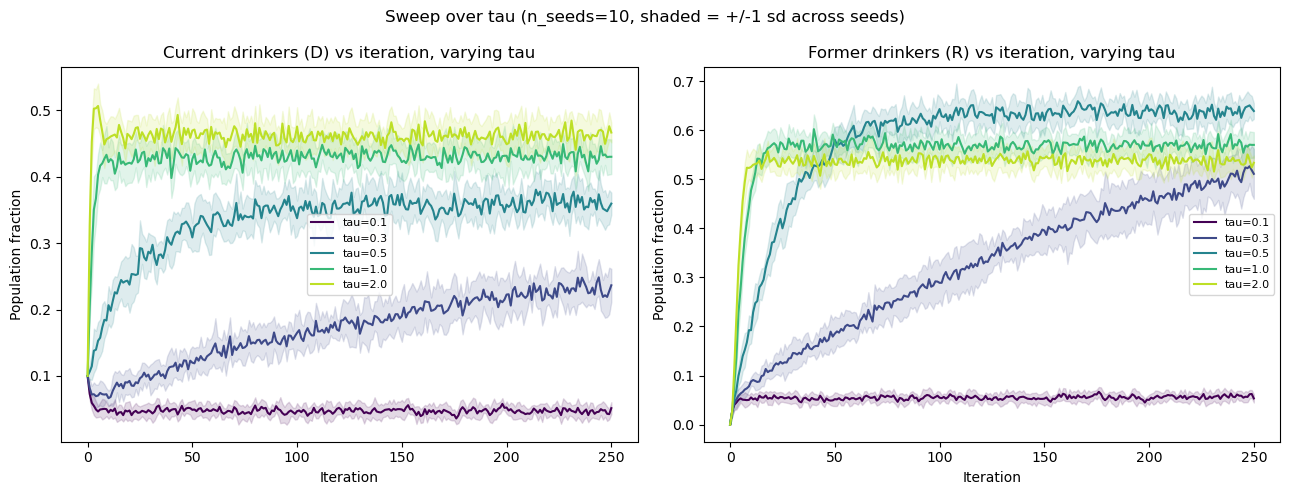

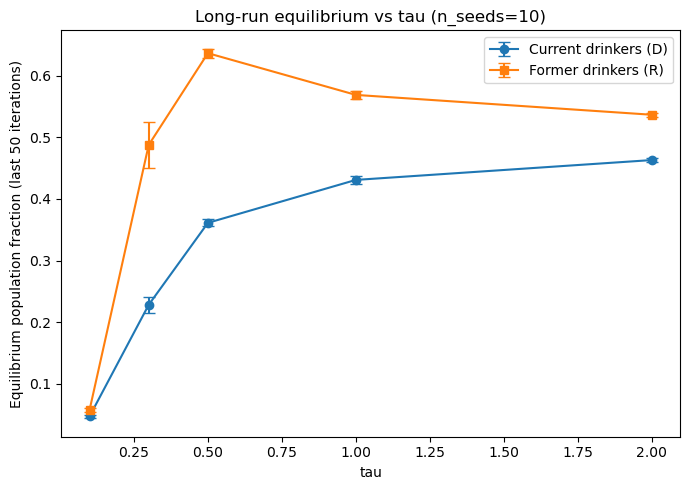

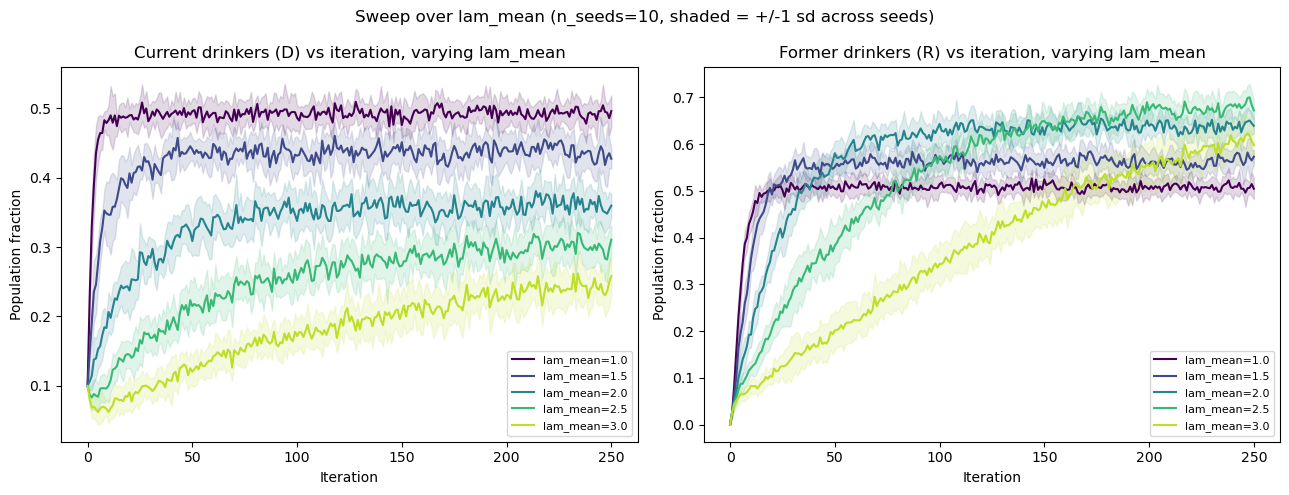

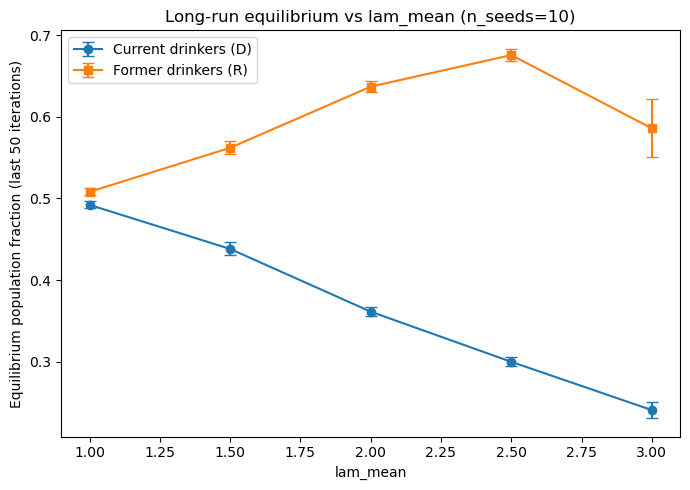

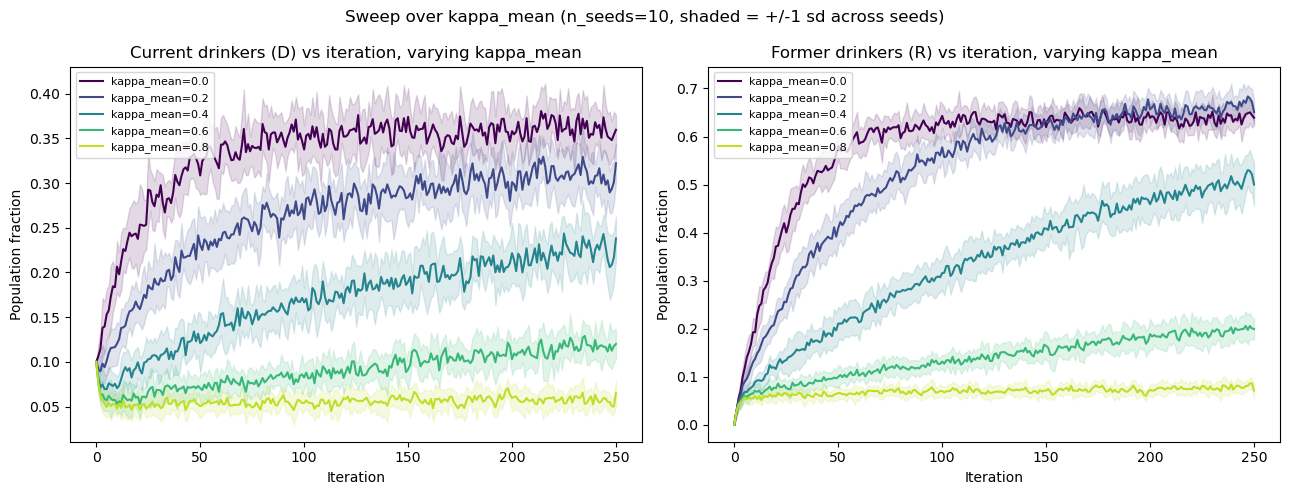

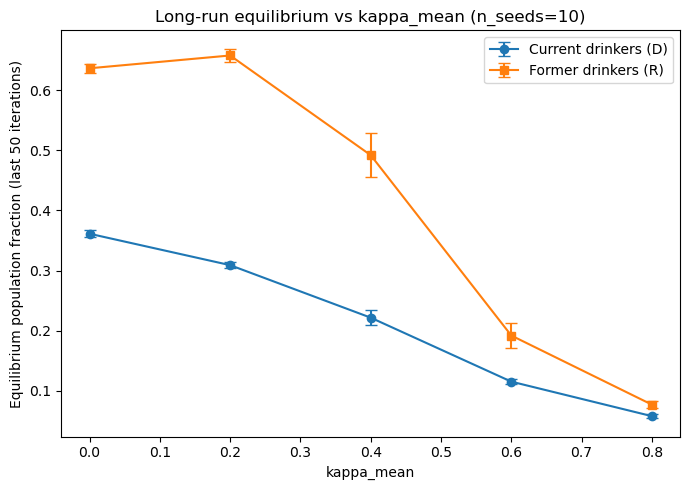

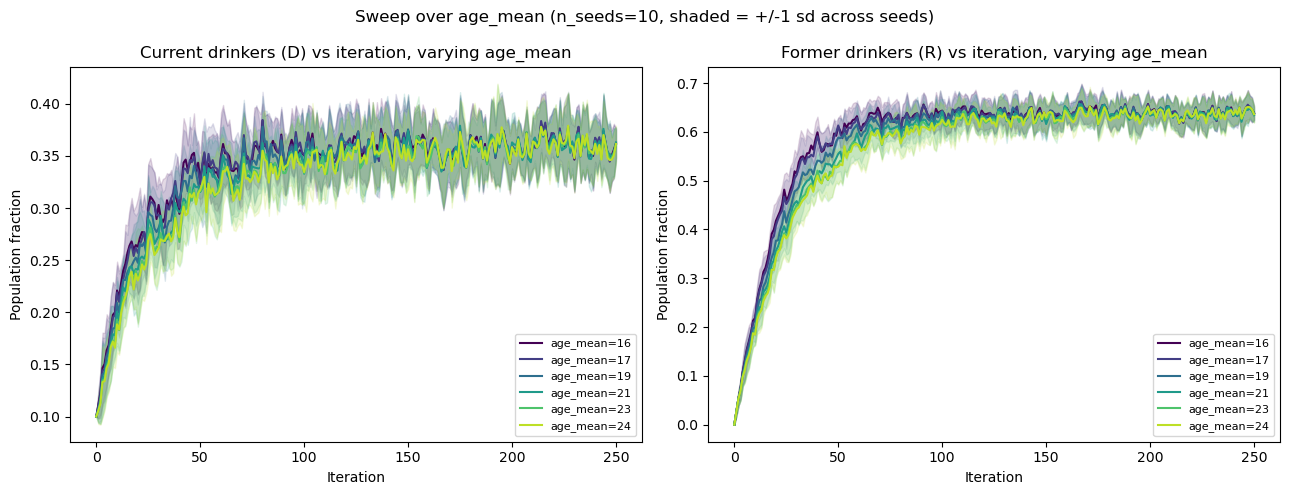

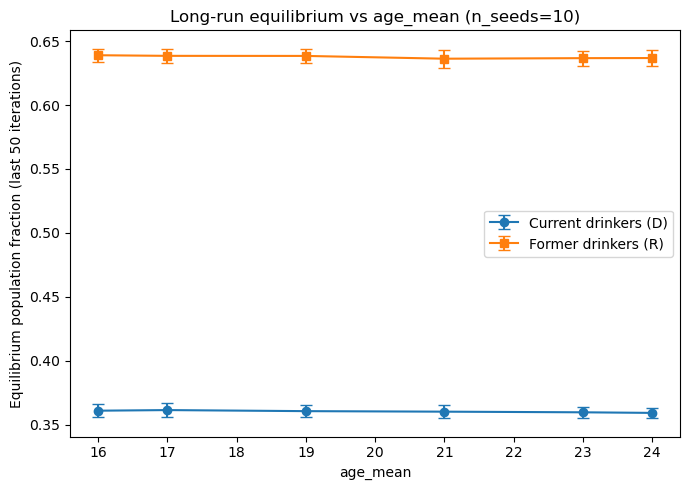

In [4]:

print("Sweep 1: tau (bounded rationality), lam_mean held fixed")
plot_trajectories_by_param("tau", TAU_VALUES, fixed={"lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})
plot_equilibrium_sensitivity("tau", TAU_VALUES, fixed={"lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})


print("Sweep 2: lam_mean (loss aversion), tau held fixed")
plot_trajectories_by_param("lam_mean", LAM_VALUES, fixed={"tau": FIXED_TAU, "kappa_mean": FIXED_KAPPA})
plot_equilibrium_sensitivity("lam_mean", LAM_VALUES, fixed={"tau": FIXED_TAU, "kappa_mean": FIXED_KAPPA})


print("Sweep 3: kappa_mean (risk aversion / curvature), tau and lam_mean held fixed")
plot_trajectories_by_param("kappa_mean", KAPPA_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM})
plot_equilibrium_sensitivity("kappa_mean", KAPPA_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM})

print("Sweep 4: age_mean, tau, lam_mean and kappa_mean held fixed")
plot_trajectories_by_param("age_mean", AGE_MEAN_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})
plot_equilibrium_sensitivity("age_mean", AGE_MEAN_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})

plt.show()